# Retail time series: do the causal-method demonstrations survive real data?

**Breakfast at the Frat · VAR · Granger · Cointegration · VECM · Toda–Yamamoto · Structural VAR**

**Business question.** How do focal-product prices and revenue interact with the other observed
cereals, and what evidence would justify interpreting a promotion as incremental revenue?

This is an empirical feasibility study, not an identified promotion-effect estimate. We distinguish
executable code, predictive usefulness, statistical adequacy, and causal identification. A method
that runs but fails a diagnostic is reported as such. We do not search for a store or specification
that produces the desired effect. No profit, retailer-wide category effect, or optimal policy is claimed.

The published source describes a representation of retail patterns. Treatment assignment is
observational. Revenue includes price changes; households/visits are product-level counts, not
deduplicated category customer totals. Missing observations are not zero sales. Inventory and costs
are unavailable. Only the selected products belong to our measured assortment.

**Run:** create the pinned environment and follow `README-retail.md`. The notebook runs offline
after the workbook has been downloaded. The small `retail_methods.py` module contains inspectable
data, testing and bootstrap helpers. All model choices, figures and conclusions are visible below.

## 1. Reproducibility and design commitments

Before looking at coefficients: use COLD CEREAL; retain every product observed in the first 52
source weeks of each store; choose the longest complete contiguous window (ties: first-year
revenue, then store ID). Select the focal product and pricing triple by first-year revenue.
This coverage-based selection is a convenience sample, not a causal target-population definition;
missingness/survival may be endogenous. Its outcome availability uses the full panel, but no
holdout sales values, model scores, p-values or effect signs select the sample.

Reserve the final 26 usable weeks for rolling forecast evaluation. All index weights and
transformation/lag selection for that evaluation use earlier data. Four lags, two annual Fourier
pairs, alpha=0.05, horizons 1/4 for forecasts and 0–12 for structural responses are fixed choices.
Model diagnostics are evaluated, not optimized until they pass. With roughly two complete years,
seasonality, structural changes and long-run inference will necessarily be uncertain.

### The decision estimand versus the quantities estimated here

A possible future experiment would assign a focal product a **one-week 5% shelf-price discount,
without feature/display support**, versus its specified no-discount schedule, followed by the
same scheduled prices in both arms. This is a proposed intervention, not a recovered assignment
mechanism in these data. Let \(g\) be a specified competitor promotion schedule and \(R^j\) revenue
for the focal product \(j=A\) or the remaining observed assortment \(j=O\). The desired contrast is

\[
\tau^j_H(g)=E\left[\sum_{h=0}^{H}\{R^j_{s,t+h}(1,g)-R^j_{s,t+h}(0,g)\}\right],
\qquad \tau^{\mathrm{observed}}_H(g)=\tau^A_H(g)+\tau^O_H(g).
\]

Weeks 0–12 include the promotion and a post-promotion window; effects beyond week 12 remain
outside this estimand. Competitor promotions and future focal promotions must be defined in both
arms. If competitor policy responds to the intervention, that defines a different policy contrast.
Assume no anticipation and specify how exposure from other stores is handled; neither is established
here. Observed negative post-promotion sales alone cannot identify purchases brought forward.

Product-level no-interference (SUTVA) is implausible: one product's promotion can change another's
sales. We keep competitors as outcomes and summarize their exposure with a fixed revenue-weighted
promotion share. This exposure mapping is lossy and is not proof that all interference is captured.

The notebook instead estimates **forecast errors, conditional lag restrictions, pricing relations,
and recursively identified innovation responses**. Its 5% innovation is not the scheduled discount
above. Contemporaneous demand forecasts, support, stockouts and central pricing can confound prices
and sales. An IPW/DR estimator would require a credible assignment model and overlap; an event-study
design would require suitable comparison episodes and parallel-trend/no-anticipation assumptions.
None is asserted from these time-series fits. The structural section therefore illustrates a
decision's sensitivity, rather than estimating \(\tau_H\).

In [1]:
from pathlib import Path
import os, sys, json, warnings, hashlib, platform, importlib.metadata
ROOT = Path.cwd()
if not (ROOT / 'retail_methods.py').exists():
    raise RuntimeError('Run with the project root as the working directory.')
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.retail-cache' / 'matplotlib'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.tsa.api import VAR
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import VECM, select_coint_rank, coint_johansen
from statsmodels.stats.multitest import multipletests
from IPython.display import display, Markdown
from retail_methods import (load_data, SOURCE_URL, SOURCE_SHA256, stationarity_table,
    calendar, select_var, toda_yamamoto, store_coverage, build_store, price_irf, bootstrap_irf)

SEED, ALPHA, HOLDOUT, MAXLAGS, BOOTSTRAPS = 42, .05, 26, 4, 399
OUT = ROOT / 'outputs' / 'retail-causal-methods'
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.figsize': (11, 4.3), 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': .2,
    'font.size': 11, 'savefig.dpi': 150})
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 140)

def table(frame, name):
    frame.to_csv(OUT / f'{name}.csv', index=False)
    display(frame)

def figure(name):
    plt.tight_layout()
    plt.savefig(OUT / f'{name}.png', bbox_inches='tight')
    plt.show()

versions = {p: importlib.metadata.version(p) for p in
    ['numpy','pandas','scipy','statsmodels','matplotlib','openpyxl','nbformat','nbclient']}
print('Python:', platform.python_version(), '| seed:', SEED)
display(pd.Series(versions, name='version'))

Python: 3.12.8 | seed: 42


numpy           2.4.6
pandas          3.0.3
scipy          1.16.3
statsmodels    0.14.6
matplotlib     3.11.0
openpyxl        3.1.5
nbformat       5.11.1
nbclient       0.11.0
Name: version, dtype: str

## 2. Data provenance and field audit

The publisher page returned HTTP 403 during acquisition. This run uses a public mirror of the
original four-sheet workbook, pinned to a Git revision and SHA-256. The hash identifies these
exact bytes; it is not certification by the publisher. Raw data are kept out of Git. The glossary
is read from the workbook, and the original cells are not repaired or overwritten.

- Publisher: https://www.dunnhumby.com/source-files/
- Mirror: https://github.com/Feanor-22/Breakfast-at-the-Frat/tree/7c58641883c787c245834bc40e89aab48da80daf
- `PRICE`: actual amount charged at shelf. `BASE_PRICE`: base price, with construction unspecified.
- `TPR_ONLY`: price reduction with shelf tag only; `FEATURE`/`DISPLAY` record additional support.

Price support flags do not document randomized assignment or an isolated price intervention.
The construction of a reference price is an additional limitation for the pricing-system analyses.

In [2]:
tables = load_data(ROOT, download=False)
transactions, products, stores, glossary = (tables[k] for k in
    ['transactions','products','stores','glossary'])
keys = ['WEEK_END_DATE','STORE_NUM','UPC']
assert not transactions.duplicated(keys).any(), 'Duplicate analysis keys require an explicit resolution.'
assert not products.UPC.duplicated().any()
# Two store IDs occur twice with conflicting segment labels. Preserve that audit
# and mark conflicting metadata unknown; never multiply transaction rows in a join.
store_duplicates = stores.loc[stores.STORE_ID.duplicated(keep=False)].sort_values('STORE_ID')
table(store_duplicates, 'duplicate_store_metadata')
conflicts = stores.groupby('STORE_ID').nunique(dropna=False).gt(1)
store_lookup = stores.groupby('STORE_ID').first().mask(conflicts).reset_index()
print('Conflicting store metadata fields:', conflicts.any().loc[lambda x:x].index.tolist())
assert not store_lookup.STORE_ID.duplicated().any()
data = transactions.merge(products, on='UPC', how='left', validate='many_to_one', indicator=True)
assert data['_merge'].eq('both').all()
data = data.drop(columns='_merge').merge(store_lookup, left_on='STORE_NUM', right_on='STORE_ID',
    how='left', validate='many_to_one', indicator=True)
assert data['_merge'].eq('both').all()
data = data.drop(columns='_merge')
weeks = pd.date_range(data.WEEK_END_DATE.min(), data.WEEK_END_DATE.max(), freq='7D')
assert set(data.WEEK_END_DATE) == set(weeks)
assert data[['FEATURE','DISPLAY','TPR_ONLY']].isin([0,1]).all().all()
assert data[['UNITS','SPEND']].ge(0).all().all()
audit = data.groupby('CATEGORY').agg(rows=('UPC','size'), products=('UPC','nunique'),
    stores=('STORE_NUM','nunique'), weeks=('WEEK_END_DATE','nunique')).reset_index()
table(audit, 'category_audit')
print('Workbook SHA-256:', SOURCE_SHA256)
print('Source dates:', weeks.min().date(), 'to', weeks.max().date(), '|',len(weeks),'weeks')
print('Lookup rows / unique stores / observed:', len(stores), '/',stores.STORE_ID.nunique(),
      '/',data.STORE_NUM.nunique(),'stores;',
      len(products),'vs',data.UPC.nunique(),'products')
table(transactions.isna().sum().rename('missing_cells').rename_axis('field').reset_index(), 'missing_fields')
display(glossary.loc[glossary['VARIABLE NAME'].isin(
    ['PRICE','BASE_PRICE','SPEND','TPR_ONLY','FEATURE','DISPLAY'])])
reconciliation = (data.SPEND - data.PRICE * data.UNITS).abs()
print('Spend vs price × units: median absolute discrepancy', round(reconciliation.median(),4),
      '; 99th percentile',round(reconciliation.quantile(.99),4))
print('Nonpositive prices:',int(data.PRICE.le(0).sum()),
      '| nonpositive reference prices:',int(data.BASE_PRICE.le(0).sum()))

,STORE_ID,STORE_NAME,ADDRESS_CITY_NAME,ADDRESS_STATE_PROV_CODE,MSA_CODE,SEG_VALUE_NAME,PARKING_SPACE_QTY,SALES_AREA_SIZE_NUM,AVG_WEEKLY_BASKETS
22,4503,ROCKWALL,ROCKWALL,TX,19100,MAINSTREAM,NaN,56230,25289.326923
61,4503,ROCKWALL,ROCKWALL,TX,19100,UPSCALE,NaN,56230,25289.326923
39,17627,FLOWER MOUND,FLOWER MOUND,TX,19100,MAINSTREAM,513.0,59213,18196.820513
54,17627,FLOWER MOUND,FLOWER MOUND,TX,19100,UPSCALE,513.0,59213,18196.820513


Conflicting store metadata fields: ['SEG_VALUE_NAME']


,CATEGORY,rows,products,stores,weeks
0,BAG SNACKS,127462,15,77,156
1,COLD CEREAL,169689,15,77,156
2,FROZEN PIZZA,111270,12,77,156
3,ORAL HYGIENE PRODUCTS,116529,13,77,156


Workbook SHA-256: 5c62464459204d6d5eea03f10cc1aca4ccaf319596a995fa54c57397b473cf1f
Source dates: 2009-01-14 to 2012-01-04 | 156 weeks
Lookup rows / unique stores / observed: 79 / 77 / 77 stores; 58 vs 55 products


,field,missing_cells
0,WEEK_END_DATE,0
1,STORE_NUM,0
2,UPC,0
3,UNITS,0
4,VISITS,0
5,HHS,0
6,SPEND,0
7,PRICE,23
8,BASE_PRICE,185
9,FEATURE,0


,VARIABLE NAME,TABLE,DESCRIPTION
3,BASE_PRICE,data,base price of item
7,DISPLAY,data,product was a part of in-store promotional dis...
8,FEATURE,data,product was in in-store circular
12,PRICE,data,actual amount charged for the product at shelf
16,SPEND,data,"total spend (i.e., $ sales)"
19,TPR_ONLY,data,"temporary price reduction only (i.e., shelf ta..."


Spend vs price × units: median absolute discrepancy 0.0 ; 99th percentile 0.0
Nonpositive prices: 1 | nonpositive reference prices: 0


In [3]:
cereal = data.loc[data.CATEGORY.eq('COLD CEREAL')].copy()
cereal['discount'] = 1 - cereal.PRICE / cereal.BASE_PRICE.where(cereal.BASE_PRICE.gt(0))
cereal['support'] = cereal.FEATURE.eq(1) | cereal.DISPLAY.eq(1)
cereal['promo_flag'] = cereal[['FEATURE','DISPLAY','TPR_ONLY']].eq(1).any(axis=1)
# Five percent is a descriptive threshold, not an assignment rule or an instrument.
cereal['discount5'] = cereal['discount'].ge(.05)
promotion_audit = cereal.groupby(['FEATURE','DISPLAY','TPR_ONLY']).agg(
    rows=('UPC','size'), median_discount=('discount','median')).reset_index()
table(promotion_audit,'promotion_packages')
store_week = cereal.groupby(['STORE_NUM','WEEK_END_DATE']).agg(
    products_observed=('UPC','nunique'), promoted_products=('promo_flag','sum'))
print('Store-weeks with >=2 products promoted:',round(store_week.promoted_products.ge(2).mean(),3))
print('Rows where shelf price exceeds base price:',int(cereal['discount'].lt(0).sum()))
print('Known zero-unit records:',int(cereal.UNITS.eq(0).sum()),
      '| missing records cannot be inferred to be zero or out of stock.')
expected_cells=cereal.STORE_NUM.nunique()*cereal.UPC.nunique()*len(weeks)
print('Unobserved cells in the store × observed-UPC × week grid:',expected_cells-len(cereal),
      '| may include products not carried; this is not a count of stockouts.')
coverage = store_coverage(cereal,weeks,baseline_weeks=52)
table(coverage.head(12).reset_index(drop=True),'store_coverage_top12')
STORE = int(coverage.iloc[0]['store'])
raw, FOCAL, ASSORTMENT, weights, wide = build_store(cereal,STORE,weeks,baseline_weeks=52)
assert len(raw) >= 100 and raw.notna().all().all()
assert coverage.iloc[0]['later_entrants'] == 0, 'Revisit the outcome boundary for later entrants.'
assert set(ASSORTMENT) == set(cereal.loc[cereal.STORE_NUM.eq(STORE),'UPC'])
assert np.all(np.diff(raw.index.values) == np.timedelta64(7,'D'))
focal_name = products.set_index('UPC').loc[FOCAL,'DESCRIPTION']
baseline = cereal.loc[cereal.STORE_NUM.eq(STORE) & cereal.WEEK_END_DATE.le(weeks[51])]
ranking = baseline.groupby('UPC').SPEND.sum().sort_values(ascending=False)
PRICING_UPCS = list(ranking.index[:3])
flow = pd.DataFrame([
    ['All categories',len(data),data.STORE_NUM.nunique(),data.UPC.nunique(),len(weeks)],
    ['Cereal',len(cereal),cereal.STORE_NUM.nunique(),cereal.UPC.nunique(),len(weeks)],
    ['Anchor complete window',len(raw)*len(ASSORTMENT),1,len(ASSORTMENT),len(raw)]
],columns=['sample','rows','stores','products','weeks'])
table(flow,'sample_flow')
display(Markdown(f'**Anchor:** store {STORE}; focal product **{focal_name}** ({FOCAL}). '
    f'All {len(ASSORTMENT)} observed cereals are retained over {len(raw)} consecutive weeks, '
    f'{raw.index.min().date()}–{raw.index.max().date()}. No missing weeks were filled with zero.'))
table(products.loc[products.UPC.isin(ASSORTMENT)].reset_index(drop=True),'retained_assortment')

,FEATURE,DISPLAY,TPR_ONLY,rows,median_discount
0,0,0,0,129473,0.000000
1,0,0,1,18619,0.161157
2,0,1,0,5374,0.183007
3,1,0,0,6667,0.201939
4,1,1,0,9556,0.255034


Store-weeks with >=2 products promoted: 0.8
Rows where shelf price exceeds base price: 678
Known zero-unit records: 1 | missing records cannot be inferred to be zero or out of stock.
Unobserved cells in the store × observed-UPC × week grid: 10491 | may include products not carried; this is not a count of stockouts.


,store,assortment_size,complete_weeks,longest_run,start,stop,baseline_revenue,later_entrants
0,613,15,107,107,25,132,65207.48,0
1,25261,15,107,107,25,132,58866.56,0
2,19533,15,107,107,25,132,55359.54,0
3,4503,15,107,106,26,132,77742.17,0
4,8263,15,106,106,27,133,49505.94,0
5,13859,15,107,106,25,131,48566.17,0
6,23345,15,107,106,26,132,42983.30,0
7,13837,15,105,105,27,132,49492.74,0
8,25229,15,105,103,27,130,72264.19,0
9,6379,15,102,102,28,130,63625.75,0


,sample,rows,stores,products,weeks
0,All categories,524950,77,55,156
1,Cereal,169689,77,15,156
2,Anchor complete window,1605,1,15,107


**Anchor:** store 613; focal product **GM HONEY NUT CHEERIOS** (1600027527). All 15 observed cereals are retained over 107 consecutive weeks, 2009-07-08–2011-07-20. No missing weeks were filled with zero.

,UPC,DESCRIPTION,MANUFACTURER,CATEGORY,SUB_CATEGORY,PRODUCT_SIZE
0,1111085319,PL HONEY NUT TOASTD OATS,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,12.25 OZ
1,1111085345,PL RAISIN BRAN,PRIVATE LABEL,COLD CEREAL,ADULT CEREAL,20 OZ
2,1111085350,PL BT SZ FRSTD SHRD WHT,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,18 OZ
3,1600027527,GM HONEY NUT CHEERIOS,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,12.25 OZ
4,1600027528,GM CHEERIOS,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,18 OZ
5,1600027564,GM CHEERIOS,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,12 OZ
6,3000006340,QKER LIFE ORIGINAL,QUAKER,COLD CEREAL,ALL FAMILY CEREAL,13 OZ
7,3000006560,QKER CAP N CRUNCH BERRIES,QUAKER,COLD CEREAL,KIDS CEREAL,13 OZ
8,3000006610,QKER CAP N CRUNCH,QUAKER,COLD CEREAL,KIDS CEREAL,14 OZ
9,3800031829,KELL BITE SIZE MINI WHEAT,KELLOGG,COLD CEREAL,ALL FAMILY CEREAL,18 OZ


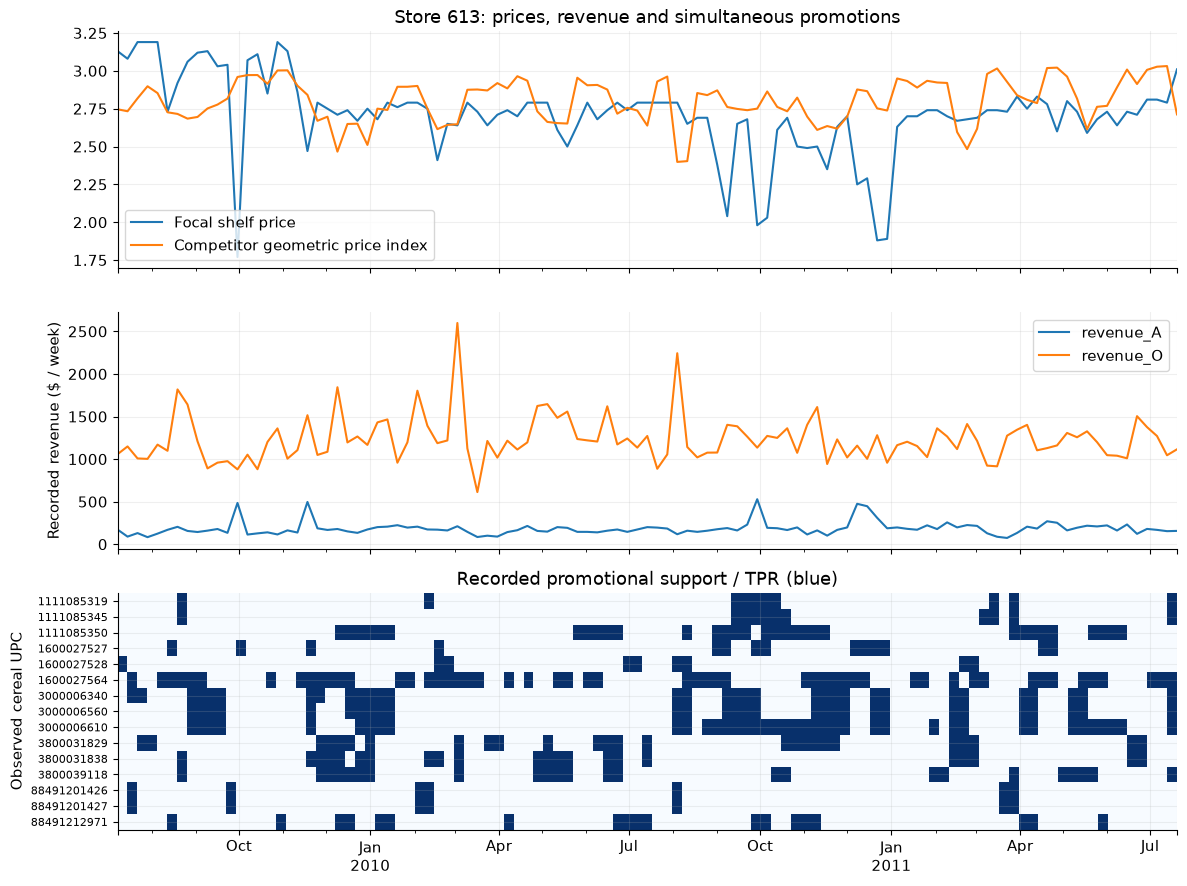

In [4]:
fig, axes = plt.subplots(3,1,figsize=(12,9),sharex=True)
np.exp(raw[['log_price_A','log_price_O']]).rename(columns={
    'log_price_A':'Focal shelf price','log_price_O':'Competitor geometric price index'}).plot(ax=axes[0])
raw[['revenue_A','revenue_O']].plot(ax=axes[1]); axes[1].set_ylabel('Recorded revenue ($ / week)')
flags = ((wide['FEATURE']+wide['DISPLAY']+wide['TPR_ONLY'])>0).astype(float)
# Missing source records must remain visually distinct from no recorded promotion.
flags = flags.where(wide['SPEND'].notna()).loc[raw.index]
axes[2].imshow(flags.T,aspect='auto',interpolation='nearest',cmap='Blues',
    extent=[plt.matplotlib.dates.date2num(raw.index[0]),plt.matplotlib.dates.date2num(raw.index[-1]),len(ASSORTMENT),0])
axes[2].set_yticks(np.arange(len(ASSORTMENT))+.5);axes[2].set_yticklabels(ASSORTMENT,fontsize=8)
axes[2].set_ylabel('Observed cereal UPC');axes[2].set_title('Recorded promotional support / TPR (blue)')
axes[0].set_title(f'Store {STORE}: prices, revenue and simultaneous promotions')
figure('01_prices_revenue_promotions')

## 3. Stationarity: an empirical decision, not a property assumed from the macro example

ADF tests a unit-root null; KPSS tests a stationarity null. Non-rejection does not prove a null.
We report constant and trend specifications, lag choices and KPSS table boundaries. Sparse
repricing, structural breaks and only a few annual cycles can make both tests unreliable.

For forecast construction only, a predeclared training-only rule keeps a series in levels when
constant-specification ADF rejects and KPSS does not. Otherwise, it uses first differences if those
meet that criterion; unresolved cases are flagged. This conservative engineering choice is **not**
a claim to have identified the integration order. The raw-levels VAR is retained as a sensitivity.

In [5]:
train_end = raw.index[-HOLDOUT]
initial_train = raw.loc[raw.index < train_end]
assert weeks[51] < train_end, 'Price-index weights must predate every held-out forecast.'
train_stationarity = stationarity_table(initial_train)
table(train_stationarity,'stationarity_training')
rules, difference_cols = [], []
for name in raw:
    tests = train_stationarity.loc[(train_stationarity['series']==name)&
                                   (train_stationarity['deterministic']=='c')].set_index('transform')
    level_ok = tests.loc['level','adf_p']<ALPHA and tests.loc['level','kpss_p']>=ALPHA
    diff_ok = tests.loc['difference','adf_p']<ALPHA and tests.loc['difference','kpss_p']>=ALPHA
    if not level_ok: difference_cols.append(name)
    rules.append({'series':name,'representation':'level' if level_ok else 'first difference',
                  'training_diagnostic_support':bool(level_ok or diff_ok)})
rules = pd.DataFrame(rules)
table(rules,'transformation_rules')
model_data = raw.copy()
model_data[difference_cols] = model_data[difference_cols].diff()
model_data = model_data.dropna()
exog = calendar(model_data.index)
train_y = model_data.loc[model_data.index < train_end]
fit_train, selection_train, bic_choice = select_var(train_y,MAXLAGS,exog.loc[train_y.index])
P = fit_train.k_ar
print('Training criteria:',selection_train.selected_orders,'| chosen lag:',P)
if bic_choice == 0: print('BIC chose zero lags; one lag is retained solely to demonstrate lag tests.')
print('Differenced variables:',difference_cols)

,series,transform,deterministic,adf_p,adf_lags,kpss_p,kpss_lags,kpss_bound
0,log_price_A,level,c,3.188884e-06,0,0.010000,4,<=0.01
1,log_price_A,level,ct,1.935164e-07,1,0.100000,1,>=0.10
2,log_price_A,difference,c,2.835701e-09,5,0.100000,29,>=0.10
3,log_price_A,difference,ct,7.059606e-08,5,0.033383,28,interior
4,log_price_O,level,c,4.206291e-06,1,0.100000,3,>=0.10
5,log_price_O,level,ct,4.477201e-05,1,0.100000,3,>=0.10
6,log_price_O,difference,c,9.600316e-09,3,0.100000,19,>=0.10
7,log_price_O,difference,ct,1.745146e-07,3,0.065773,19,interior
8,revenue_A,level,c,2.177945e-09,0,0.100000,3,>=0.10
9,revenue_A,level,ct,1.336887e-08,0,0.100000,2,>=0.10


,series,representation,training_diagnostic_support
0,log_price_A,first difference,True
1,log_price_O,level,True
2,revenue_A,level,True
3,revenue_O,level,True


Training criteria: {'aic': np.int64(1), 'bic': np.int64(0), 'hqic': np.int64(1), 'fpe': np.int64(1)} | chosen lag: 1
BIC chose zero lags; one lag is retained solely to demonstrate lag tests.
Differenced variables: ['log_price_A']


## 4. VAR: a genuine forecasting comparison

The four-dimensional system jointly predicts focal and competitor prices/revenue, with known
calendar Fourier terms. Every forecast uses only information available at its origin; future realised
prices and promotional flags are not supplied. Compare the joint VAR with separate AR models
using the same lag order/calendar terms, last-value forecasts, 52-week seasonal-naive forecasts,
and a calendar-only model. The last benchmark represents a zero-lag alternative when BIC selects
VAR(0); the one-lag minimum in the demonstration is not presented as a BIC-selected optimum.

Evaluate 1- and 4-week horizons, refitting at each origin with fixed training-selected transformations
and lag order. Revenue components are summed for the assortment comparison. Forecast performance
is not an estimate of causal uplift. A known future promotion schedule would define a different,
conditional forecasting task.

,horizon,target,method,MAE,RMSE,n
0,1,observed_assortment,AR,140.206214,178.474333,26
1,1,observed_assortment,VAR,140.804990,179.928710,26
2,1,observed_assortment,calendar_only,140.528104,179.852144,26
3,1,observed_assortment,last_value,155.483846,194.406271,26
4,1,observed_assortment,seasonal_naive,251.138846,364.582058,26
5,1,revenue_A,AR,40.171240,48.460297,26
6,1,revenue_A,VAR,40.037377,48.515092,26
7,1,revenue_A,calendar_only,42.035087,52.065813,26
8,1,revenue_A,last_value,44.772308,53.991298,26
9,1,revenue_A,seasonal_naive,38.969615,46.767150,26


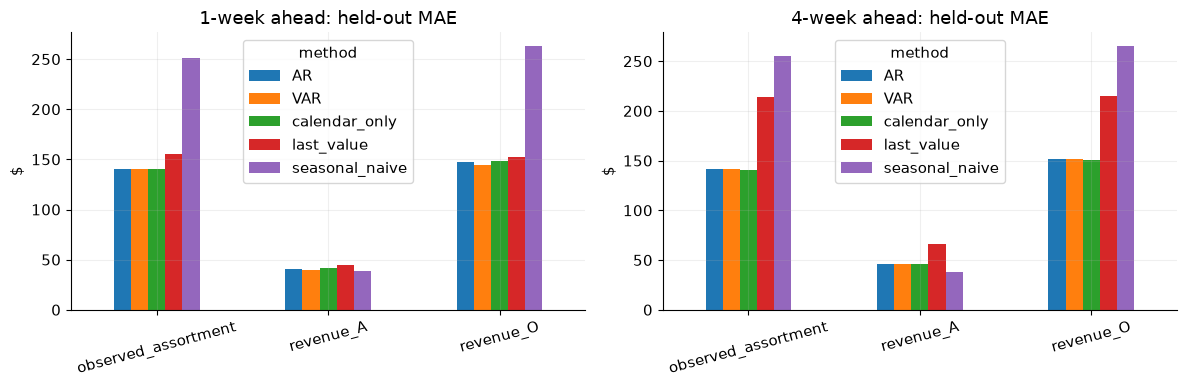

In [6]:
forecast_records=[]
first_origin=model_data.index.get_loc(train_end)
for h in [1,4]:
    for origin in range(first_origin,len(model_data)-h+1):
        history=model_data.iloc[:origin]; future=model_data.index[origin:origin+h]
        hist_x=exog.loc[history.index]; future_x=exog.loc[future]
        v=VAR(history,exog=hist_x).fit(P,trend='c')
        joint=v.forecast(history.to_numpy()[-P:],h,exog_future=future_x.to_numpy())
        predictions={}
        for name in ['revenue_A','revenue_O']:
            col=model_data.columns.get_loc(name)
            ar=AutoReg(history[name],lags=P,trend='c',exog=hist_x,old_names=False).fit()
            separate=np.asarray(ar.predict(start=len(history),end=len(history)+h-1,exog_oos=future_x))
            calendar_fit=sm.OLS(history[name],sm.add_constant(hist_x,has_constant='add')).fit()
            calendar_pred=np.asarray(calendar_fit.predict(sm.add_constant(future_x,has_constant='add')))
            joint_col=joint[:,col]
            if name in difference_cols:
                last=raw.loc[history.index[-1],name]
                joint_col=last+np.cumsum(joint_col); separate=last+np.cumsum(separate)
                calendar_pred=last+np.cumsum(calendar_pred)
            predictions[name]={'VAR':joint_col[-1],'AR':separate[-1],
                'calendar_only':calendar_pred[-1],
                'last_value':raw.loc[history.index[-1],name],
                'seasonal_naive':raw.loc[future[-1]-pd.Timedelta(weeks=52),name]}
        for target in ['revenue_A','revenue_O','observed_assortment']:
            names=['revenue_A','revenue_O'] if target=='observed_assortment' else [target]
            actual=raw.loc[future[-1],names].sum()
            for method in ['VAR','AR','calendar_only','last_value','seasonal_naive']:
                pred=sum(predictions[n][method] for n in names)
                forecast_records.append(dict(origin=history.index[-1],date=future[-1],horizon=h,
                    target=target,method=method,actual=actual,prediction=pred,error=actual-pred))
forecasts=pd.DataFrame(forecast_records)
forecast_scores=forecasts.groupby(['horizon','target','method']).error.agg(
    MAE=lambda x:np.abs(x).mean(),RMSE=lambda x:np.sqrt(np.mean(x*x)),n='size').reset_index()
table(forecast_scores,'forecast_scores')
forecasts.to_csv(OUT/'forecast_predictions.csv',index=False)
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,h in zip(axes,[1,4]):
    subset=forecast_scores.query('horizon==@h').pivot(index='target',columns='method',values='MAE')
    subset.plot.bar(ax=ax,rot=15);ax.set_title(f'{h}-week ahead: held-out MAE');ax.set_ylabel('$');ax.set_xlabel('')
figure('02_forecast_comparison')

In [7]:
# Paired moving-block uncertainty for the VAR-minus-AR absolute-error difference.
# Negative values favour VAR. This is predictive uncertainty, not a treatment-effect CI.
rng=np.random.default_rng(SEED)
forecast_intervals=[]
for h in [1,4]:
    errors=forecasts.query('horizon==@h and target=="observed_assortment"').pivot(
        index='origin',columns='method',values='error')
    delta=errors['VAR'].abs().to_numpy()-errors['AR'].abs().to_numpy()
    draws=[];n=len(delta)
    for _ in range(999):
        starts=rng.integers(0,n,size=int(np.ceil(n/4)))
        ix=np.concatenate([(s+np.arange(4))%n for s in starts])[:n]
        draws.append(delta[ix].mean())
    lo,hi=np.quantile(draws,[.025,.975])
    forecast_intervals.append(dict(horizon=h,MAE_difference=delta.mean(),low=lo,high=hi,
        reliable_VAR_advantage=bool(hi<0),origins=n))
forecast_intervals=pd.DataFrame(forecast_intervals)
table(forecast_intervals,'forecast_paired_intervals')

# Explanatory models now use the full selected window; they are NOT held-out effect estimates.
fit=VAR(model_data,exog=exog).fit(P,trend='c')
diagnostics=[]
for label,frame in [('chosen_representation',model_data),('raw_levels_sensitivity',raw)]:
    for lag in range(1,MAXLAGS+1):
        r=VAR(frame,exog=calendar(frame.index)).fit(lag,trend='c')
        diagnostics.append(dict(specification=label,lag=lag,bic=r.bic,stable=r.is_stable(),
            whiteness_p=r.test_whiteness(nlags=12,adjusted=True).pvalue,
            normality_p=r.test_normality().pvalue,parameters_per_equation=len(r.params),observations=r.nobs))
diagnostics=pd.DataFrame(diagnostics)
table(diagnostics,'var_diagnostics')
chosen=diagnostics.query('specification=="chosen_representation" and lag==@P').iloc[0]
var_adequate=bool(chosen.stable and chosen.whiteness_p>=ALPHA and rules.training_diagnostic_support.all())
display(Markdown('**VAR adequacy:** '+('passes these limited screens' if var_adequate else
    'not established; interpret subsequent Wald tests and intervals as conditional diagnostics')+'. '
    'Gaussian normality, stability and residual whiteness are separate questions.'))

,horizon,MAE_difference,low,high,reliable_VAR_advantage,origins
0,1,0.598776,-3.071214,4.451070,False,26
1,4,0.220099,-0.535642,0.857449,False,23


,specification,lag,bic,stable,whiteness_p,normality_p,parameters_per_equation,observations
0,chosen_representation,1,9.834320,True,0.038784,8.681585e-115,9,105
1,chosen_representation,2,10.249031,True,0.072966,4.001896e-146,13,104
2,chosen_representation,3,10.709667,True,0.113988,1.012793e-151,17,103
3,chosen_representation,4,11.228078,True,0.107359,1.014392e-152,21,102
4,raw_levels_sensitivity,1,9.488793,True,0.140964,7.107058e-120,9,106
5,raw_levels_sensitivity,2,10.062931,True,0.121601,5.776830e-106,13,105
6,raw_levels_sensitivity,3,10.503540,True,0.245692,1.515060e-121,17,104
7,raw_levels_sensitivity,4,11.019653,True,0.150678,6.766577e-119,21,103


**VAR adequacy:** not established; interpret subsequent Wald tests and intervals as conditional diagnostics. Gaussian normality, stability and residual whiteness are separate questions.

## 5. Granger: predictive precedence, including retailer feedback

Test four directional hypotheses chosen in advance: focal price → own revenue, focal price →
competitor revenue, competitor price → focal revenue, and own revenue → focal price. In a
differenced-price equation these concern **repricing**, not the original level. Each null jointly
sets the first p cross-lag coefficients to zero. Conditioning includes the remaining system and
calendar terms; it cannot remove unobserved inventory, advertising or anticipated demand.

Holm correction covers the four primary tests. Lag-grid results below are a separate exploratory
family, adjusted over all 16 tests. A small p-value is not a large effect. A missing lagged relation
does not rule out a same-week promotion effect. The competing assortment is an outcome, not an
unaffected causal control.

In [8]:
links=[('log_price_A','revenue_A'),('log_price_A','revenue_O'),
       ('log_price_O','revenue_A'),('revenue_A','log_price_A')]
gc=[]
for cause,effect in links:
    test=fit.test_causality(effect,cause,kind='f')
    gc.append(dict(cause=cause,effect=effect,pvalue=test.pvalue,F=test.test_statistic))
gc=pd.DataFrame(gc)
gc['p_holm']=multipletests(gc.pvalue,method='holm')[1]
gc['reject_holm']=gc.p_holm<ALPHA
gc['diagnostics_adequate']=var_adequate
table(gc,'granger_primary')
gc_grid=[]
for lag in range(1,MAXLAGS+1):
    r=VAR(model_data,exog=exog).fit(lag)
    for cause,effect in links:
        gc_grid.append(dict(lag=lag,cause=cause,effect=effect,pvalue=r.test_causality(effect,cause).pvalue))
gc_grid=pd.DataFrame(gc_grid)
gc_grid['p_holm_grid']=multipletests(gc_grid.pvalue,method='holm')[1]
table(gc_grid,'granger_lag_sensitivity')

,cause,effect,pvalue,F,p_holm,reject_holm,diagnostics_adequate
0,log_price_A,revenue_A,0.487978,0.481911,1.0,False,False
1,log_price_A,revenue_O,0.468951,0.525489,1.0,False,False
2,log_price_O,revenue_A,0.462609,0.540658,1.0,False,False
3,revenue_A,log_price_A,0.478091,0.504200,1.0,False,False


,lag,cause,effect,pvalue,p_holm_grid
0,1,log_price_A,revenue_A,0.487978,1.000000
1,1,log_price_A,revenue_O,0.468951,1.000000
2,1,log_price_O,revenue_A,0.462609,1.000000
3,1,revenue_A,log_price_A,0.478091,1.000000
4,2,log_price_A,revenue_A,0.240038,1.000000
5,2,log_price_A,revenue_O,0.707264,1.000000
6,2,log_price_O,revenue_A,0.479321,1.000000
7,2,revenue_A,log_price_A,0.927869,1.000000
8,3,log_price_A,revenue_A,0.045988,0.643838
9,3,log_price_A,revenue_O,0.744152,1.000000


## 6. Cointegration: regular pricing, not a manufactured sales equilibrium

Use the three highest-revenue products in the first source year; no pair is chosen by its p-value.
Unit-root tests use both intercept and trend specifications. Distinct repricing dates and visible
breaks are reported because piecewise-constant reference prices can mimic persistent processes.

Engle–Granger uses its calibrated residual-based distribution (`coint`), not ordinary ADF critical
values applied to estimated residuals. Johansen rank is shown across deterministic specifications
and lag orders. Full rank is evidence against the maintained all-I(1) specification, not three
economic equilibria. The default constant Johansen case is matched to VECM `deterministic='co'`.

,series,UPC,description
0,base_A,1600027527,GM HONEY NUT CHEERIOS
1,base_B,1600027528,GM CHEERIOS
2,base_C,3800031838,KELL FROSTED FLAKES


,series,distinct_prices,repricing_weeks,largest_log_change
0,base_A,34,78,0.112702
1,base_B,11,19,0.069472
2,base_C,35,60,0.098325


,series,transform,deterministic,adf_p,adf_lags,kpss_p,kpss_lags,kpss_bound
0,base_A,level,c,1.114338e-01,2,0.010000,5,<=0.01
1,base_A,level,ct,6.610330e-01,2,0.010000,5,<=0.01
2,base_A,difference,c,1.445287e-17,1,0.083177,17,interior
3,base_A,difference,ct,7.067472e-16,1,0.100000,20,>=0.10
4,base_B,level,c,9.738444e-02,1,0.010000,5,<=0.01
5,base_B,level,ct,1.406904e-02,1,0.010000,5,<=0.01
6,base_B,difference,c,1.089227e-08,5,0.100000,10,>=0.10
7,base_B,difference,ct,1.123385e-07,5,0.100000,10,>=0.10
8,base_C,level,c,2.490806e-02,1,0.010000,5,<=0.01
9,base_C,level,ct,2.225716e-04,6,0.100000,5,>=0.10


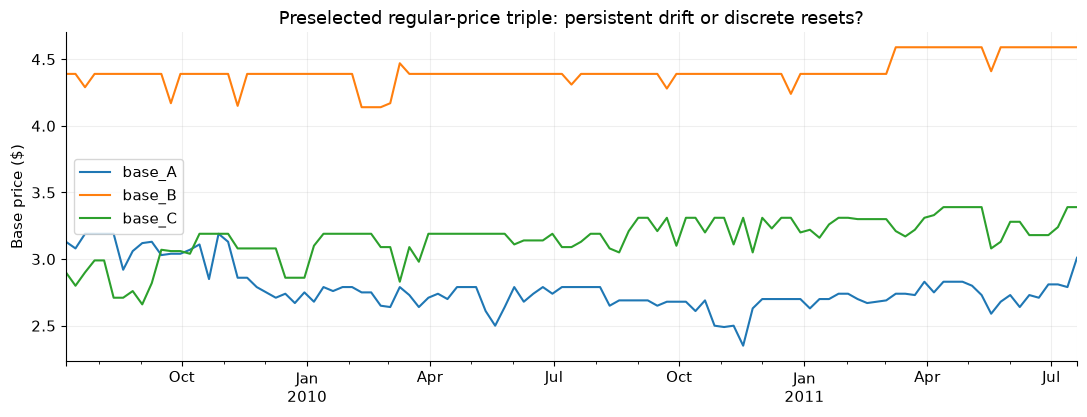

,trend,lag,statistic,pvalue
0,c,1,-2.604159,0.235158
1,c,2,-2.498306,0.279817
2,c,3,-2.677806,0.207662
3,c,4,-2.690226,0.203114
4,ct,1,-2.991650,0.267394
5,ct,2,-3.002600,0.262626
6,ct,3,-3.234617,0.173222
7,ct,4,-3.032352,0.249934


,deterministic_order,difference_lags,rank
0,-1,1,1
1,-1,2,1
2,-1,3,1
3,0,1,1
4,0,2,1
5,0,3,1
6,1,1,3
7,1,2,2
8,1,3,2


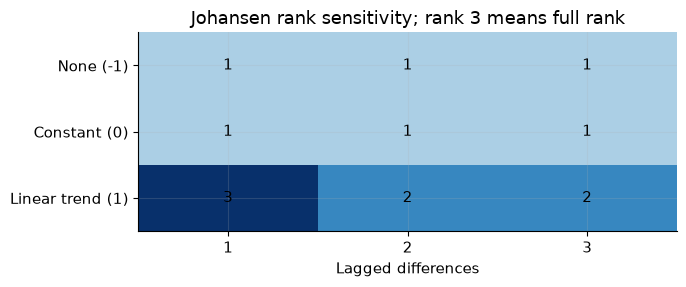

**Conservative empirical screen:** all three series plausibly I(1) across both deterministic specifications: **False**; a common reduced rank across the grid: **False**. This screen is deliberately strict and does not establish causality.

In [9]:
base=np.log(wide['BASE_PRICE'].loc[raw.index,PRICING_UPCS])
base.columns=['base_A','base_B','base_C']
price_mapping=pd.DataFrame({'series':base.columns,'UPC':PRICING_UPCS,
    'description':[products.set_index('UPC').loc[u,'DESCRIPTION'] for u in PRICING_UPCS]})
table(price_mapping,'pricing_triple')
price_audit=pd.DataFrame({'series':base.columns,'distinct_prices':base.nunique().values,
    'repricing_weeks':base.diff().abs().gt(1e-8).sum().values,
    'largest_log_change':base.diff().abs().max().values})
table(price_audit,'base_price_variation')
base_stationarity=stationarity_table(base)
table(base_stationarity,'base_price_stationarity')
np.exp(base).plot(title='Preselected regular-price triple: persistent drift or discrete resets?')
plt.ylabel('Base price ($)');figure('03_base_prices')
eg=[]
for trend in ['c','ct']:
    for lag in [1,2,3,4]:
        statistic,pvalue,critical=coint(base.base_A,base.base_B,trend=trend,maxlag=lag,autolag=None)
        eg.append(dict(trend=trend,lag=lag,statistic=statistic,pvalue=pvalue))
eg=pd.DataFrame(eg);table(eg,'engle_granger_sensitivity')
rank_records=[]
for det in [-1,0,1]:
    for diff_lags in [1,2,3]:
        rank=select_coint_rank(base,det_order=det,k_ar_diff=diff_lags,method='trace',signif=ALPHA).rank
        rank_records.append(dict(deterministic_order=det,difference_lags=diff_lags,rank=rank))
ranks=pd.DataFrame(rank_records);table(ranks,'johansen_sensitivity')
rank_grid=ranks.pivot(index='deterministic_order',columns='difference_lags',values='rank')
fig,ax=plt.subplots(figsize=(7,3));ax.imshow(rank_grid,cmap='Blues',vmin=0,vmax=3,aspect='auto')
ax.set_xticks(range(3),rank_grid.columns);ax.set_yticks(range(3),['None (-1)','Constant (0)','Linear trend (1)'])
for i in range(3):
    for j in range(3):ax.text(j,i,str(rank_grid.iloc[i,j]),ha='center',va='center')
ax.set_xlabel('Lagged differences');ax.set_title('Johansen rank sensitivity; rank 3 means full rank')
figure('04_cointegration_rank')
# Conservative evidence screen; it is neither a theorem nor proof of I(1).
i1_flags=[]
for name in base:
    for det in ['c','ct']:
        t=base_stationarity.query('series==@name and deterministic==@det').set_index('transform')
        i1_flags.append(t.loc['level','adf_p']>=ALPHA and t.loc['level','kpss_p']<ALPHA
            and t.loc['difference','adf_p']<ALPHA and t.loc['difference','kpss_p']>=ALPHA)
i1_supported=bool(all(i1_flags))
rank_stable=bool(ranks['rank'].nunique()==1 and 0<int(ranks['rank'].iloc[0])<3)
cointegration_supported=i1_supported and rank_stable
display(Markdown(f'**Conservative empirical screen:** all three series plausibly I(1) across both '
    f'deterministic specifications: **{i1_supported}**; a common reduced rank across the grid: '
    f'**{rank_stable}**. This screen is deliberately strict and does not establish causality.'))

## 7. VECM: execute a conditional model and make its status explicit

The next fit is an **illustration conditional on a selected rank**, not an endorsement if the
cointegration screen failed. Use the prespecified constant case with two lagged differences,
matching `co` in estimation to the Johansen constant specification. If it selects rank zero or
full rank, skip the reduced-rank model rather than force rank one.

Beta describes a relative-price relationship. Alpha is each equation's loading on the normalized
error-correction term, not a universal percentage of the gap closed. Include uncertainty and the
full deterministic terms. Adjustment is predictive pricing behaviour; common supplier costs or
central schedules can explain it without causal price leadership.

,series,relation,beta,beta_se,alpha,alpha_se,alpha_p
0,base_A,1,1.000000,0.000000,-0.147894,0.047285,0.001762
1,base_B,1,-2.111623,0.575996,0.017558,0.024332,0.470548
2,base_C,1,1.569639,0.252681,-0.193956,0.047797,0.000050


,series,unrestricted_intercept,intercept_se
0,base_A,-0.047734,0.015012
1,base_B,0.006398,0.007725
2,base_C,-0.058045,0.015175


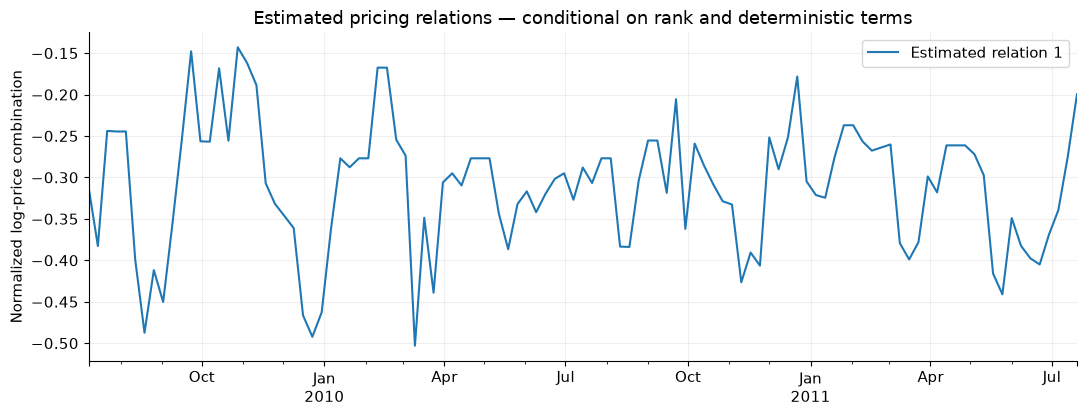

selected_rank                         1
whiteness_p                    0.076328
cointegration_screen_passed       False
dtype: object

In [10]:
VECM_DIFF_LAGS=2
selected_rank=int(select_coint_rank(base,det_order=0,k_ar_diff=VECM_DIFF_LAGS).rank)
vecm_ran=0<selected_rank<base.shape[1]
vecm_diagnostics={}
if vecm_ran:
    vecm=VECM(base,k_ar_diff=VECM_DIFF_LAGS,coint_rank=selected_rank,deterministic='co').fit()
    coefs=[]
    for relation in range(selected_rank):
        for i,name in enumerate(base.columns):
            coefs.append(dict(series=name,relation=relation+1,beta=vecm.beta[i,relation],
                beta_se=vecm.stderr_beta[i,relation],
                alpha=vecm.alpha[i,relation],alpha_se=vecm.stderr_alpha[i,relation],
                alpha_p=vecm.pvalues_alpha[i,relation]))
    table(pd.DataFrame(coefs),'vecm_coefficients')
    table(pd.DataFrame({'series':base.columns,'unrestricted_intercept':vecm.det_coef[:,0],
        'intercept_se':vecm.stderr_det_coef[:,0]}),'vecm_deterministic_terms')
    ect=pd.DataFrame(base.to_numpy() @ vecm.beta,index=base.index,
                     columns=[f'Estimated relation {j+1}' for j in range(selected_rank)])
    ect.plot(title='Estimated pricing relations — conditional on rank and deterministic terms')
    plt.ylabel('Normalized log-price combination');figure('05_vecm_relations')
    vecm_diagnostics={'selected_rank':selected_rank,'whiteness_p':float(vecm.test_whiteness(12,adjusted=True).pvalue),
                      'cointegration_screen_passed':cointegration_supported}
    display(pd.Series(vecm_diagnostics))
    # Independent specification check: Johansen eigenvector matches the fitted co case for rank 1.
    if selected_rank==1:
        eigen=coint_johansen(base,0,VECM_DIFF_LAGS).evec[:,0]
        np.testing.assert_allclose(vecm.beta[:,0],eigen/eigen[0],atol=1e-5)
else:
    display(Markdown(f'**Reduced-rank VECM skipped:** the preselected case returned rank {selected_rank}.'))

## 8. Toda–Yamamoto: predictive restrictions without fixing cointegration rank

Use the same regular-price triple in levels. Choose the baseline lag by BIC, augment by d_max=1,
and test only the baseline lags. First-difference diagnostics assess whether one additional lag is
a plausible allowance; do not interpret non-rejection as a proof of the integration bound.
The helper uses labelled covariance entries and is tested against equation-level Wald tests.

Holm correction covers all six directions in the primary fit. The lag-augmentation grid is
exploratory and separately corrected across its entire family. TY does not remove omitted-variable
bias, identify an intervention, or exclusively test a short-run mechanism. Calendar terms and
the maximum integration order remain assumptions.

In [11]:
ty_exog=calendar(base.index)
ty_selection=VAR(base,exog=ty_exog).select_order(MAXLAGS)
TY_P=max(1,int(ty_selection.selected_orders['bic']))
ty_rows=[]
for cause in base:
    for effect in base:
        if cause==effect:continue
        result,ty_fit=toda_yamamoto(base,cause,effect,TY_P,1,exog=ty_exog)
        ty_rows.append(result)
ty=pd.DataFrame(ty_rows);ty['p_holm']=multipletests(ty.pvalue,method='holm')[1]
ty_white=float(ty_fit.test_whiteness(12,adjusted=True).pvalue)
ty['reject_holm']=ty.p_holm<ALPHA
table(ty,'toda_yamamoto_primary')
print('Base lag:',TY_P,'| augmented lag:',TY_P+1,'| augmented-model whiteness p:',round(ty_white,5))
ty_grid=[]
for p in sorted(set([max(1,TY_P-1),TY_P,min(MAXLAGS,TY_P+1)])):
    for dmax in [1,2]:
        for cause,effect in [('base_A','base_B'),('base_B','base_A')]:
            result,_=toda_yamamoto(base,cause,effect,p,dmax,exog=ty_exog);ty_grid.append(result)
ty_grid=pd.DataFrame(ty_grid);ty_grid['p_holm_grid']=multipletests(ty_grid.pvalue,method='holm')[1]
table(ty_grid,'toda_yamamoto_sensitivity')

,p,dmax,cause,effect,wald,df,pvalue,p_holm,reject_holm
0,1,1,base_A,base_B,0.002738,1,0.958268,1.000000,False
1,1,1,base_A,base_C,1.650932,1,0.198832,0.994161,False
2,1,1,base_B,base_A,0.111256,1,0.738719,1.000000,False
3,1,1,base_B,base_C,2.872193,1,0.090122,0.540732,False
4,1,1,base_C,base_A,0.184981,1,0.667127,1.000000,False
5,1,1,base_C,base_B,1.018794,1,0.312805,1.000000,False


Base lag: 1 | augmented lag: 2 | augmented-model whiteness p: 0.04336


,p,dmax,cause,effect,wald,df,pvalue,p_holm_grid
0,1,1,base_A,base_B,0.002738,1,0.958268,1.0
1,1,1,base_B,base_A,0.111256,1,0.738719,1.0
2,1,2,base_A,base_B,0.054152,1,0.815989,1.0
3,1,2,base_B,base_A,0.390674,1,0.531945,1.0
4,2,1,base_A,base_B,4.093399,2,0.129160,1.0
5,2,1,base_B,base_A,0.478890,2,0.787064,1.0
6,2,2,base_A,base_B,2.886515,2,0.236157,1.0
7,2,2,base_B,base_A,0.612784,2,0.736098,1.0


## 9. Structural VAR: a price-innovation sensitivity exercise

Use the same reduced-form dynamics with different recursive identifications. Orthogonalizing
residuals is algebra; it does not establish that an innovation is exogenous to expected demand.
The data contain simultaneous promotions and unobserved inventory/retailer forecasts. There is
no valid instrument or randomized schedule here. Support flags are not instruments: they can
directly affect sales.

1. **Focal price first:** prices precede weekly demand; competitor price can respond to focal price.
2. **Competitor price first:** reverse the contemporaneous pricing hierarchy.
3. **Demand first:** pricing may respond contemporaneously to sales innovations.

In the demand-first ordering, the price shock's impact on revenue at week zero is constrained
to zero. That zero is imposed by the identifying restrictions, not learned as an empirical effect.
This Cholesky factorization implements a just-identified recursive SVAR; using a separate `SVAR`
class is not required for this identification. Other structural restrictions would be different models.

Normalize each shock to a **5% focal price reduction on impact**, an analyst-defined scenario.
This is not a one-week campaign held fixed: future prices evolve according to the fitted system.
If the focal price is differenced, cumulate its response to recover the log-price path. Likewise
restore any differenced revenue before summing weekly revenue. Forecasts of prices, not
experimental assignment probabilities, determine these responses.

Intervals use 399 common moving-block residual bootstrap draws (four-week blocks). They include
parameter uncertainty conditional on the chosen sample/lag/specification, not identification or
model-selection uncertainty. Failures of model diagnostics remain failures even with bootstrap
bands. The bands are pointwise, not simultaneous across horizons or identification choices.

Observed focal week-to-week price changes (quantiles):


0.05   -0.141234
0.25   -0.020831
0.50    0.000000
0.75    0.026591
0.95    0.119261
Name: log_price_A, dtype: float64

Observed shelf/base discounts (quantiles):


0.05    0.000000
0.50    0.000000
0.95    0.219145
Name: 1600027527, dtype: float64

Bootstrap fits retained: 399 | numerical failures: 0


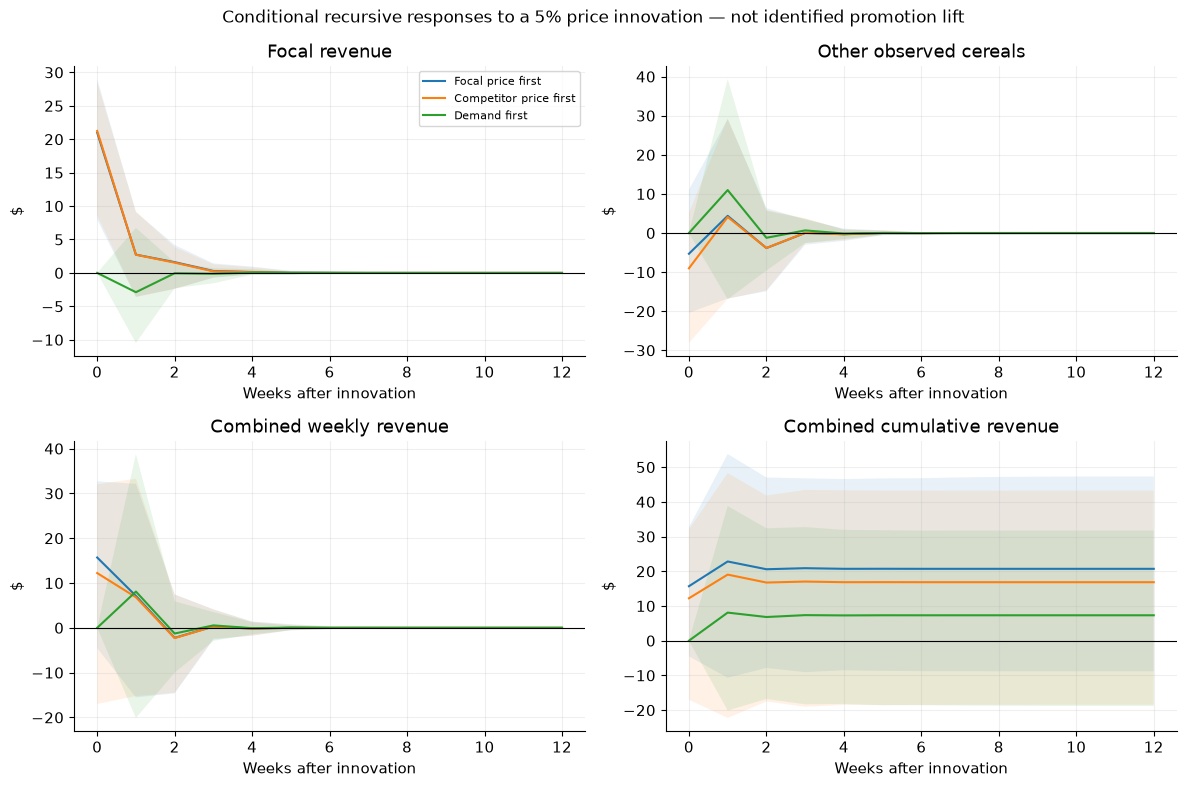

,order,end_week,focal,others,combined,low,high
0,Focal price first,0,20.995537,-5.299611,15.695926,-4.522068,32.702609
1,Focal price first,4,25.759468,-5.051379,20.708088,-8.530077,46.564495
2,Focal price first,8,25.787946,-5.081569,20.706377,-8.820753,47.175112
3,Focal price first,12,25.786900,-5.080617,20.706283,-8.830632,47.326139
4,Competitor price first,0,21.242159,-9.019661,12.222498,-17.008960,32.024330
5,Competitor price first,4,25.834443,-8.981914,16.852529,-18.519409,43.303281
6,Competitor price first,8,25.834584,-8.984243,16.850341,-18.460304,43.212217
7,Competitor price first,12,25.832401,-8.982061,16.850339,-18.446741,43.210629
8,Demand first,0,0.000000,0.000000,0.000000,0.000000,0.000000
9,Demand first,4,-3.016589,10.299395,7.282806,-18.220209,31.918092


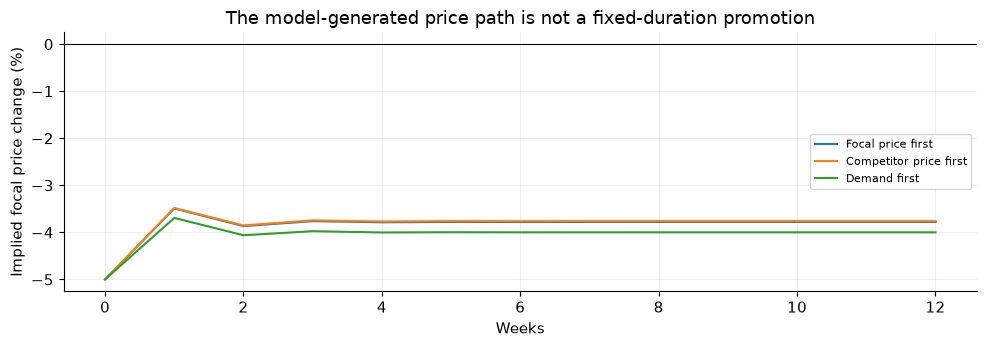

In [12]:
ORDERS={
    'Focal price first':['log_price_A','log_price_O','revenue_A','revenue_O'],
    'Competitor price first':['log_price_O','log_price_A','revenue_A','revenue_O'],
    'Demand first':['revenue_A','revenue_O','log_price_O','log_price_A'],
}
H=12; PRICE_CHANGE=-.05
print('Observed focal week-to-week price changes (quantiles):')
display(np.expm1(raw.log_price_A.diff()).quantile([.05,.25,.5,.75,.95]))
print('Observed shelf/base discounts (quantiles):')
display((1-wide['PRICE'].loc[raw.index,FOCAL]/wide['BASE_PRICE'].loc[raw.index,FOCAL]).quantile([.05,.5,.95]))
def restore_levels(a):
    out=a.copy()
    for col in difference_cols:
        j=list(model_data).index(col)
        out[...,j]=np.cumsum(out[...,j],axis=-1)
    return out

responses={name:restore_levels(price_irf(fit,order,H,PRICE_CHANGE)) for name,order in ORDERS.items()}
boot,bootstrap_failures=bootstrap_irf(fit,model_data,exog,ORDERS,H,PRICE_CHANGE,
                                     draws=BOOTSTRAPS,block=4,seed=SEED)
boot={name:restore_levels(a) for name,a in boot.items()}
assert all(len(a)>=.95*BOOTSTRAPS for a in boot.values()), 'Too many failed bootstrap fits.'
print('Bootstrap fits retained:',len(next(iter(boot.values()))),'| numerical failures:',bootstrap_failures)
revenue_idx=[list(model_data).index(x) for x in ['revenue_A','revenue_O']]
fig,axes=plt.subplots(2,2,figsize=(12,8))
for name,response in responses.items():
    focal,other=response[:,revenue_idx[0]],response[:,revenue_idx[1]]
    panels=[focal,other,focal+other,np.cumsum(focal+other)]
    b=boot[name];bf,bo=b[:,:,revenue_idx[0]],b[:,:,revenue_idx[1]]
    bp=[bf,bo,bf+bo,np.cumsum(bf+bo,axis=1)]
    for ax,line,draws in zip(axes.flat,panels,bp):
        lo,hi=np.quantile(draws,[.025,.975],axis=0)
        ax.plot(range(H+1),line,label=name);ax.fill_between(range(H+1),lo,hi,alpha=.10)
for ax,title in zip(axes.flat,['Focal revenue','Other observed cereals','Combined weekly revenue','Combined cumulative revenue']):
    ax.axhline(0,color='black',lw=.8);ax.set_title(title);ax.set_xlabel('Weeks after innovation');ax.set_ylabel('$')
axes[0,0].legend(fontsize=8)
fig.suptitle('Conditional recursive responses to a 5% price innovation — not identified promotion lift',fontsize=12)
figure('06_structural_revenue_responses')

structural=[]
for name,a in responses.items():
    b=boot[name];j,k=revenue_idx
    for end in [0,4,8,12]:
        combined=(b[:,:end+1,j]+b[:,:end+1,k]).sum(axis=1)
        lo,hi=np.quantile(combined,[.025,.975])
        structural.append(dict(order=name,end_week=end,focal=a[:end+1,j].sum(),
            others=a[:end+1,k].sum(),combined=(a[:end+1,j]+a[:end+1,k]).sum(),low=lo,high=hi))
structural=pd.DataFrame(structural)
np.testing.assert_allclose(structural.focal+structural.others,structural.combined)
table(structural,'structural_cumulative_sensitivity')
fig,ax=plt.subplots(figsize=(10,3.6))
for name,a in responses.items():
    ax.plot(range(H+1),100*np.expm1(a[:,list(model_data).index('log_price_A')]),label=name)
ax.axhline(0,color='black',lw=.8);ax.set_ylabel('Implied focal price change (%)');ax.set_xlabel('Weeks')
ax.set_title('The model-generated price path is not a fixed-duration promotion');ax.legend(fontsize=8)
figure('07_structural_price_paths')

## 10. Replication across stores and transparent failure modes

Repeat the same coverage-based workflow on the next four stores. Each store retains its full
first-year observed assortment and chooses its own baseline top seller. This checks portability
of the time-series demonstration; it is **not a heterogeneous causal-effect estimate**, and different
focal products make direct response rankings inappropriate. Shared campaigns also make stores
dependent; no independent-store pooled significance claim is made.

The primary four-variable system omits details of promotional packages. A sensitivity adds
lagged focal merchandising support and lagged competitor promotion exposure, known at the
prediction origin. This is predictive conditioning, not an exogeneity claim or a pure discount effect.

In [13]:
store_results=[]
for row in coverage.head(5).itertuples():
    zz,ff,uu,ww,dd=build_store(cereal,row.store,weeks,52)
    train=zz.iloc[:-HOLDOUT]
    ss=stationarity_table(train)
    change=[]
    for col in zz:
        t=ss.query('series==@col and deterministic=="c"').set_index('transform')
        if not(t.loc['level','adf_p']<ALPHA and t.loc['level','kpss_p']>=ALPHA):change.append(col)
    yy=zz.copy();yy[change]=yy[change].diff();yy=yy.dropna()
    train=yy.loc[yy.index<zz.index[-HOLDOUT]]
    rr,_,_=select_var(train,MAXLAGS,calendar(train.index))
    rr=VAR(yy,exog=calendar(yy.index)).fit(rr.k_ar)
    store_results.append(dict(store=row.store,focal=ff,products=len(uu),weeks=len(zz),lag=rr.k_ar,
        differenced=', '.join(change),stable=rr.is_stable(),whiteness_p=rr.test_whiteness(12,adjusted=True).pvalue))
store_results=pd.DataFrame(store_results);table(store_results,'store_replication')

support=pd.DataFrame(index=raw.index)
support['focal_merchandising']=(wide['FEATURE'][FOCAL].eq(1)|wide['DISPLAY'][FOCAL].eq(1)).astype(float)
rival_flags=(wide['FEATURE']+wide['DISPLAY']+wide['TPR_ONLY']).gt(0).astype(float)
support['competitor_promo_share']=rival_flags.loc[raw.index,weights.index].mul(weights).sum(axis=1)
lagged_support=support.shift(1).reindex(model_data.index)
support_x=pd.concat([exog,lagged_support],axis=1).dropna()
support_fit=VAR(model_data.loc[support_x.index],exog=support_x).fit(P)
support_tests=[]
for cause,effect in links:
    support_tests.append(dict(cause=cause,effect=effect,pvalue=support_fit.test_causality(effect,cause).pvalue))
support_tests=pd.DataFrame(support_tests)
support_tests['p_holm']=multipletests(support_tests.pvalue,method='holm')[1]
table(support_tests,'granger_support_sensitivity')
print('Lagged-support model whiteness p:',round(support_fit.test_whiteness(12,adjusted=True).pvalue,5))

,store,focal,products,weeks,lag,differenced,stable,whiteness_p
0,613,1600027527,15,107,1,log_price_A,True,0.038784
1,25261,1600027527,15,107,1,log_price_A,True,0.010251
2,19533,1600027527,15,107,1,log_price_A,True,0.221908
3,4503,1600027527,15,106,1,log_price_A,True,0.000406
4,8263,1600027527,15,106,1,"log_price_A, revenue_O",True,0.007732


,cause,effect,pvalue,p_holm
0,log_price_A,revenue_A,0.561156,1.000000
1,log_price_A,revenue_O,0.397675,1.000000
2,log_price_O,revenue_A,0.526878,1.000000
3,revenue_A,log_price_A,0.249252,0.997008


Lagged-support model whiteness p: 0.06608


## 11. Empirical success scorecard and business interpretation

Success has four levels: code executes; a predictive model is useful; its statistical assumptions
are reasonably supported; a causal intervention is identified. These are separate judgements.
The scorecard below is generated from this run, not written to guarantee positive results.

Negative responses for competitors would be consistent with substitution **within the model**;
negative later revenue would be consistent with purchases brought forward. Aggregate data cannot
establish household switching or stockpiling. Unobserved stockouts can also generate these patterns.
No interval in this notebook captures the uncertainty from an invalid identification assumption.

In [14]:
vecm_ok=bool(vecm_ran and cointegration_supported and vecm_diagnostics.get('whiteness_p',0)>=ALPHA)
ty_diff=base_stationarity.query('transform=="difference" and deterministic=="c"')
ty_bound=bool((ty_diff.adf_p<ALPHA).all() and (ty_diff.kpss_p>=ALPHA).all())
scorecard=pd.DataFrame([
    ['VAR','Executed', 'Limited support' if var_adequate else 'Diagnostics not fully supported',
     f'{int(forecast_intervals.reliable_VAR_advantage.sum())}/2 horizons show a paired MAE advantage over AR',False],
    ['Granger','Executed','Conditional on VAR adequacy',
     f'{int(gc.reject_holm.sum())}/4 primary hypotheses reject after Holm; predictive only',False],
    ['Cointegration','Executed','Supported by conservative screen' if cointegration_supported else 'Not robustly established',
     f'I(1) screen={i1_supported}; ranks observed={sorted(ranks["rank"].unique().tolist())}',False],
    ['VECM','Executed conditionally' if vecm_ran else 'Skipped by rank rule',
     'Limited support' if vecm_ok else 'Illustration; prerequisites/diagnostics not fully supported',
     f'Prespecified-case rank={selected_rank}',False],
    ['Toda–Yamamoto','Executed','Conditional diagnostics pass' if ty_bound and ty_white>=ALPHA else 'Diagnostics not fully supported',
     f'{int(ty.reject_holm.sum())}/6 directions reject after Holm; whiteness p={ty_white:.3g}',False],
    ['Structural VAR','Executed under 3 orderings','Identification remains assumed',
     'Price innovation is not a documented randomized promotion package',False]
],columns=['method','execution','empirical_status','finding','causal_promotion_effect_identified'])
table(scorecard,'empirical_scorecard')
main_h=structural.query('end_week==8')
ordering_range=[float(main_h.combined.min()),float(main_h.combined.max())]
focal_first=main_h.loc[main_h.order.eq('Focal price first')].iloc[0]
all_cross_zero=bool(((main_h.low<=0)&(main_h.high>=0)).all())
summary={'source_url':SOURCE_URL,'source_sha256':SOURCE_SHA256,'versions':versions,
    'python':platform.python_version(),'category':'COLD CEREAL','store':STORE,'focal_upc':FOCAL,
    'focal_description':focal_name,'products':ASSORTMENT,'weeks':len(raw),
    'start':str(raw.index[0].date()),'end':str(raw.index[-1].date()),
    'holdout_weeks':HOLDOUT,'lag':P,'difference_cols':difference_cols,
    'training_bic_selected_lag':bic_choice,
    'var_adequate':var_adequate,'cointegration_supported':cointegration_supported,
    'vecm':vecm_diagnostics,'ty_whiteness_p':ty_white,
    'structural_week_0_to_8_range':ordering_range,'bootstrap_repetitions':BOOTSTRAPS,
    'all_ordering_intervals_include_zero_week_0_to_8':all_cross_zero,
    'bootstrap_numerical_failures':bootstrap_failures,
    'causal_promotion_effect_identified':False,
    'scorecard':scorecard.to_dict(orient='records')}
(OUT/'run_summary.json').write_text(json.dumps(summary,indent=2))
display(Markdown(f'''**Decision:** this notebook does not justify selecting a promotion by an estimated causal lift.
Its structural week-0-to-8 cumulative revenue scenarios range from **${ordering_range[0]:,.0f} to
${ordering_range[1]:,.0f}** across the three assumed orderings, before accounting for unmeasured
confounding or model misspecification. All three conditional 95% intervals include zero: **{all_cross_zero}**.
These are scenario outputs, not empirical incremental revenue.

**How the decision changes:** under the focal-price-first assumption, looking only at the promoted
product suggests **${focal_first.focal:.1f}** in cumulative revenue, whereas including the other observed
cereals gives **${focal_first.combined:.1f}**. The competitor component is **${focal_first.others:.1f}**.
That arithmetic illustrates why gross product uplift is the wrong decision target, but the
uncertainty and identifying assumptions prevent even this smaller number from justifying a campaign.
Failure to reject the predictive tests also does not prove that real promotions have no effect.

**What the retail transfer teaches:** {len(raw)} usable weeks and {len(ASSORTMENT)} observed products
are sufficient to execute the methods, but not to make all their assumptions true. The pricing
and demand systems answer different questions. The next step for a promotion decision is a
documented intervention/comparison design (or a suitable randomized experiment), with outcomes
covering the observed competing assortment and sufficient post-promotion history.'''))

,method,execution,empirical_status,finding,causal_promotion_effect_identified
0,VAR,Executed,Diagnostics not fully supported,0/2 horizons show a paired MAE advantage over AR,False
1,Granger,Executed,Conditional on VAR adequacy,0/4 primary hypotheses reject after Holm; pred...,False
2,Cointegration,Executed,Not robustly established,"I(1) screen=False; ranks observed=[1, 2, 3]",False
3,VECM,Executed conditionally,Illustration; prerequisites/diagnostics not fu...,Prespecified-case rank=1,False
4,Toda–Yamamoto,Executed,Diagnostics not fully supported,0/6 directions reject after Holm; whiteness p=...,False
5,Structural VAR,Executed under 3 orderings,Identification remains assumed,Price innovation is not a documented randomize...,False


**Decision:** this notebook does not justify selecting a promotion by an estimated causal lift.
Its structural week-0-to-8 cumulative revenue scenarios range from **$7 to
$21** across the three assumed orderings, before accounting for unmeasured
confounding or model misspecification. All three conditional 95% intervals include zero: **True**.
These are scenario outputs, not empirical incremental revenue.

**How the decision changes:** under the focal-price-first assumption, looking only at the promoted
product suggests **$25.8** in cumulative revenue, whereas including the other observed
cereals gives **$20.7**. The competitor component is **$-5.1**.
That arithmetic illustrates why gross product uplift is the wrong decision target, but the
uncertainty and identifying assumptions prevent even this smaller number from justifying a campaign.
Failure to reject the predictive tests also does not prove that real promotions have no effect.

**What the retail transfer teaches:** 107 usable weeks and 15 observed products
are sufficient to execute the methods, but not to make all their assumptions true. The pricing
and demand systems answer different questions. The next step for a promotion decision is a
documented intervention/comparison design (or a suitable randomized experiment), with outcomes
covering the observed competing assortment and sufficient post-promotion history.

### What belongs in the retail causal-inference sequel

Start by auditing actual discount/support **episodes**, their assignment and comparison groups.
An IPW or doubly robust analysis would need credible measured confounders, overlap/balance diagnostics,
and time-aware cross-fitting. A suitable event study would need a design that handles recurrent
promotions, simultaneous competitor exposure and carryover, with pre-period falsification checks;
its assumptions differ from selection on observables. Generic lead tests are not valid placebos
when retailers anticipate demand. Such checks cannot repair unmeasured confounding.

Only after establishing a defensible effect estimand should store/product demand conditions be
used for heterogeneous-effect estimation and incremental-effect targeting. Compare this with sales
targeting out of sample, respecting shared campaigns and temporal dependence. A capacity or budget
allocation exercise then needs documented costs and counterfactual values; missing margins/costs
would have to be labelled hypothetical. We do not optimize the unvalidated SVAR scenarios or turn
observed revenue into profit. This notebook establishes the feasibility and limits of the episode-9
time-series techniques; it does not claim to complete that subsequent observational-policy study.

## References and reproducibility boundary

- [dunnhumby Source Files](https://www.dunnhumby.com/source-files/): publisher and dataset scope.
- [Pinned workbook mirror](https://github.com/Feanor-22/Breakfast-at-the-Frat/tree/7c58641883c787c245834bc40e89aab48da80daf): acquisition source; see hash above.
- [Statsmodels VAR](https://www.statsmodels.org/stable/vector_ar.html): dynamics, restrictions and recursive responses.
- [Statsmodels VECM](https://www.statsmodels.org/stable/generated/statsmodels.tsa.vector_ar.vecm.VECM.html): deterministic-term conventions.
- [Toda and Yamamoto (1995)](https://doi.org/10.1016/0304-4076(94)01616-8): augmented levels tests.

All tables and figures are exported to `outputs/retail-causal-methods/`. No raw data are substituted
with simulated observations. The only simulated quantities are labelled bootstrap resamples and
the conditional structural price-innovation scenario. Re-running the notebook overwrites its own
exported results, not the original macro notebook.